# The directional HC envelope, visualised

How `beta(r)` becomes a per-unit re-weighting of the horizontal-connection kernel, in six figures.

```
lat_c(p) = N(c,p) * sum_q { W_c(q) * E_p(q) * h_c(p+q) }

  E_p(q) = exp( vec(p) . q )      vec(p) = beta(r_p) * rhat_p = (a(p), b(p))
  N(c,p) = sum_q |W_c(q)| / sum_q |W_c(q) E_p(q)|
```

The chain this notebook walks:

| | |
|---|---|
| **1** | `beta(r)` — one learned number per eccentricity |
| **2** | `vec(p) = beta * rhat` — a vector field, one arrow per position |
| **3** | `E_p(q) = exp(vec . q)` — that arrow becomes an exponential ramp over the 11x11 window |
| **4** | `W_c * E_p` — the ramp re-weights the taps, sliding the centre of mass |
| **5** | the same `beta` buys different px in different channels |
| **6** | the achieved displacement field over the whole map |

Needs the repo on `sys.path`. The checkpoint is optional — without it the notebook falls back to a
`[dr]` log line plus a synthetic Gabor bank, and says so.

In [1]:
import math, os, re, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================ CONFIG ============================
REPO     = "/exports/home/tomasdu/repos/plastic_NNs"
CKPT     = ("/home/tomasdu/repos/experiments/plastic_NNs/active/WS-S/wandb/"
            "offline-run-20260908_223210-41xkud1m/files/model/epoch_0029.pth")
HW       = (156, 156)     # stage-0 feature map
BETA_MAX = 0.640          # MUST match config.model.directional_beta_max for the run
TAPER_PX = 3.0
K_STEPS  = 3
# used ONLY if CKPT is missing -- paste a run's own "[dr]" line
LOG_LINE = ("[dr] ep49 stages.0.0  w=[+0.36 -0.74 -0.13]  c=[16.4 34.1 43.5]px  "
            "s=[1.14 1.00 2.61]px  b=+0.469")
ZONES = dict(core=23.84, rfov=29.88, footprint=41.70)   # measured, feature-map px
# ================================================================

KERNEL_KEY, SHIFT_KEY = "stages.0.0.lateral.weight", "stages.0.0.lateral_shift"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
os.chdir(REPO)
from src.models.utils.radial_shift import RadialShift
from src.experiments.hc.plot_gate_kernel_evolution import load_sd   # NB: this module calls
# matplotlib.use("Agg") at import time, which silently disables inline figures. Undo it AFTER the
# import or every plt.show() below is a no-op with a "non-GUI backend" warning.
%matplotlib inline

torch.set_grad_enabled(False)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9.5,
                     "axes.spines.top": False, "axes.spines.right": False})

rs = RadialShift(input_size=HW, k_steps=K_STEPS, beta_max=BETA_MAX, taper_px=TAPER_PX)
if os.path.isfile(CKPT):
    sd  = load_sd(CKPT)
    rs.load_state_dict({k.split(SHIFT_KEY + ".")[1]: v.float()
                        for k, v in sd.items() if k.startswith(SHIFT_KEY + ".")})
    Wk = sd[KERNEL_KEY].float()
    W  = Wk.reshape(-1, Wk.shape[-2], Wk.shape[-1])
    SOURCE = f"checkpoint {os.path.basename(CKPT)}"
else:
    vec_ = lambda t: [float(x) for x in re.search(rf"\b{t}=\[([^\]]*)\]", LOG_LINE).group(1).split()]
    rs.weight[0] = torch.tensor(vec_("w")); rs.centre[0] = torch.tensor(vec_("c"))
    rs._width[0] = torch.log(torch.expm1(torch.tensor(vec_("s"))))
    rs.bias[0, 0] = float(re.search(r"\bb=([-+]?[0-9.]+)", LOG_LINE).group(1))
    from src.models.utils.gabor_init import make_gabor_bank
    W = make_gabor_bank(n_kernels=32, kernel_size=11)
    SOURCE = "the [dr] log line + a synthetic Gabor bank (CKPT not found)"

C_N, KS = W.shape[0], W.shape[-1]
PAD  = KS // 2
A, B = rs()                       # (1,H,W) each -- the polarity vector field
Aa, Bb, BETA = A[0], B[0], rs.beta()[0]
QQ   = torch.arange(KS, dtype=torch.float32) - PAD
QY, QX = QQ.view(KS, 1).expand(KS, KS), QQ.view(1, KS).expand(KS, KS)
CY = (HW[0] - 1) / 2.0

def envelope(p):
    """E_p(q) over the whole (k,k) window for the unit at p=(y,x)."""
    return torch.exp(float(Aa[p]) * QX + float(Bb[p]) * QY)

def com(M):
    """|w|-centre of mass of a (k,k) kernel, (dy,dx) in px from the centre tap."""
    m = M.abs(); t = float(m.sum())
    return float((m.sum(1) * QQ).sum() / t), float((m.sum(0) * QQ).sum() / t)

def l1(M, base):
    """the block's renormalisation: pin sum|w| back to `base`."""
    return M * (base / float(M.abs().sum()))

def at_ecc(r, deg):
    """the map position at eccentricity r and polar angle deg."""
    return (int(round(CY + r * math.sin(math.radians(deg)))),
            int(round(CY + r * math.cos(math.radians(deg)))))

def info(p):
    return dict(r=float(rs.r[p]), beta=float(BETA[p]), a=float(Aa[p]), b=float(Bb[p]),
                th=math.degrees(math.atan2(float(rs.sin_t[p]), float(rs.cos_t[p]))))

print(f"source  : {SOURCE}")
print(f"kernels : {tuple(W.shape)}      map: {HW}      beta_max: {BETA_MAX} 1/px")
print(f"beta over the map: {float(BETA.min()):+.4f} .. {float(BETA.max()):+.4f} 1/px")

/home/tomasdu/miniconda3/envs/plastic_NNs-ssh/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/exports/home/tomasdu/miniconda3/envs/plastic_NNs-ssh/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


/home/tomasdu/miniconda3/envs/plastic_NNs-ssh/lib/python3.8/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


the fisheye sees you


source  : checkpoint epoch_0029.pth
kernels : (32, 11, 11)      map: (156, 156)      beta_max: 0.64 1/px
beta over the map: -0.0264 .. +0.3821 1/px


---
## 1 & 2 — `beta(r)`, and the vector field it defines

**Left** is the learned profile: one number per eccentricity. Its **sign** says which way the unit
looks, its **magnitude** is in e-folds per pixel.

**Right** turns that into `vec(p) = beta(r_p) * rhat_p` — one arrow per position, pointing along the
unit's own outward radius, with length `|beta|`. Where `beta < 0` the arrow flips and points at the
fovea. Everything at the same eccentricity gets the same length; only the direction differs.

Nothing is "aimed" yet. This is still just a field of numbers.

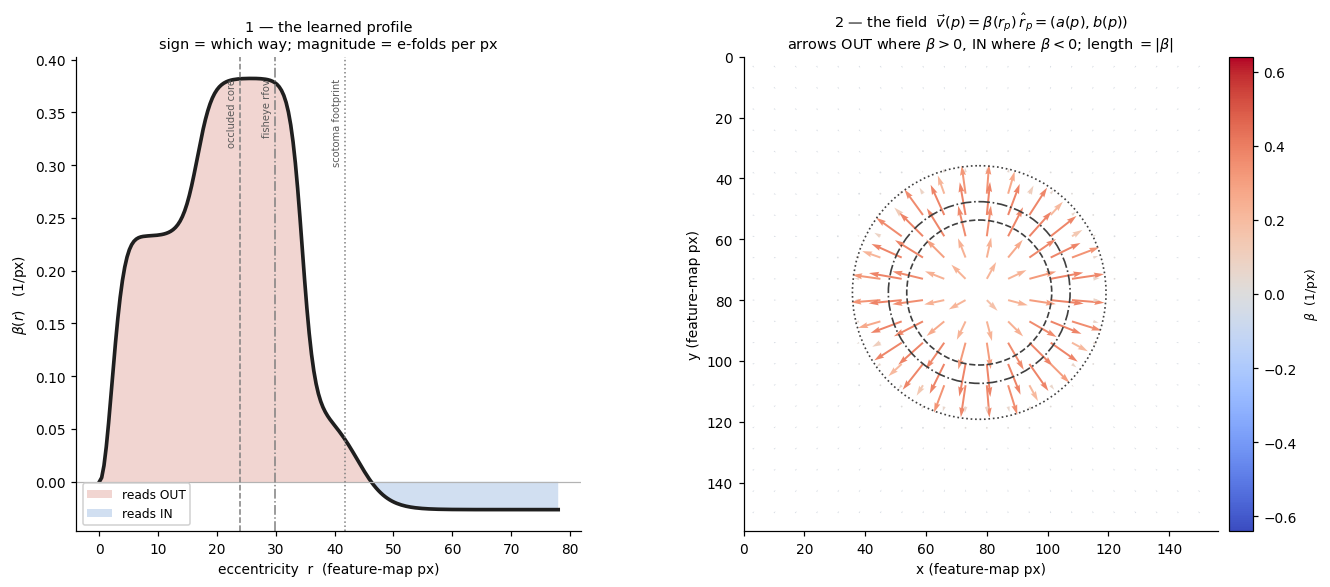

self-check: of 6,364 positions with 2 < r < 45, 6,364 have vec . rhat > 0 (100.0%) -> all pointing OUTWARD, as the profile says

17,628 of 24,336 positions (72.4%) have beta < 0 -> those arrows point INWARD.
  BUT read the magnitudes before reading that number: the inward region is the far field (r > 46 px, i.e. the map CORNERS, past the 42 px scotoma footprint), and its
  strongest |beta| is only 0.0264 1/px against 0.3821 outward. Most of the map's AREA is at large r; most of its POLARITY is not.


In [1]:
fig = plt.figure(figsize=(13.8, 5.6))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.22)

# ---------- left: beta(r) ----------
ax = fig.add_subplot(gs[0])
rr, prof = rs.profile(r_max=78.0)
rr, prof = rr.numpy(), prof[0].numpy()
ax.fill_between(rr, 0, prof, where=prof >= 0, color="#c1442e", alpha=0.22, lw=0, label="reads OUT")
ax.fill_between(rr, 0, prof, where=prof <= 0, color="#2e6fc1", alpha=0.22, lw=0, label="reads IN")
ax.plot(rr, prof, lw=2.4, color="0.12")
ax.axhline(0, color="0.7", lw=0.8)
for r0, ls, lab in ((ZONES["core"], "--", "occluded core"), (ZONES["rfov"], "-.", "fisheye rfov"),
                    (ZONES["footprint"], ":", "scotoma footprint")):
    ax.axvline(r0, color="0.5", lw=1.0, ls=ls)
    ax.annotate(lab, (r0, prof.max()), rotation=90, fontsize=6.5, color="0.35",
                va="top", ha="right", xytext=(-2, 0), textcoords="offset points")
ax.set_xlabel("eccentricity  r  (feature-map px)")
ax.set_ylabel(r"$\beta(r)$   (1/px)")
ax.set_title("1 — the learned profile\nsign = which way; magnitude = e-folds per px")
ax.legend(fontsize=8, loc="lower left", framealpha=0.9)

# ---------- right: the vector field ----------
ax = fig.add_subplot(gs[1]); ax.set_aspect("equal")
st = 7
ys, xs = np.mgrid[3:HW[0]:st, 3:HW[1]:st]
u, v   = Aa.numpy()[3::st, 3::st], Bb.numpy()[3::st, 3::st]
col    = BETA.numpy()[3::st, 3::st]
# QUIVER ON AN INVERTED Y AXIS: angles="xy" is MANDATORY here, not a preference.
# matplotlib defaults to angles="uv", which resolves the arrow direction in SCREEN space (y up).
# These axes are image-style inverted (set_ylim(H, 0)), so with the default the VERTICAL component
# is drawn BACKWARDS while the horizontal one is not: arrows above and below the fovea flip to point
# inward while left/right still point outward, and the field renders as a saddle that is not there.
# Verified: with angles="uv" a V=+1 arrow draws UP on an inverted axis; with angles="xy" it draws
# DOWN, which is what "data y increases" means here. scale_units="xy" then puts the LENGTH in
# feature-map px too, so `scale` reads as "vector magnitude per px of arrow".
q = ax.quiver(xs, ys, u, v, col, cmap="coolwarm", pivot="tail", angles="xy",
              scale_units="xy", scale=0.035,
              norm=plt.Normalize(-BETA_MAX, BETA_MAX), width=0.0042)
for r0, ls in ((ZONES["core"], "--"), (ZONES["rfov"], "-."), (ZONES["footprint"], ":")):
    ax.add_patch(Circle((CY, CY), r0, fill=False, ec="0.25", lw=1.1, ls=ls, zorder=4))
ax.set_xlim(0, HW[1]); ax.set_ylim(HW[0], 0)
ax.set_xlabel("x (feature-map px)"); ax.set_ylabel("y (feature-map px)")
ax.set_title(r"2 — the field  $\vec{v}(p)=\beta(r_p)\,\hat r_p=(a(p),b(p))$" "\n"
             "arrows OUT where $\\beta>0$, IN where $\\beta<0$; length $=|\\beta|$")
cb = fig.colorbar(q, ax=ax, fraction=0.043, pad=0.02)
cb.set_label(r"$\beta$  (1/px)", fontsize=8)
plt.show()

# SELF-CHECK on the rendering: inside the sign change every arrow must point AWAY from the
# fovea, i.e. vec(p) . rhat_p > 0. This is what the angles="uv" default silently broke.
_rad = torch.sqrt((torch.arange(HW[0]).view(-1,1) - CY)**2 + (torch.arange(HW[1]).view(1,-1) - CY)**2)
_inner = (_rad > 2) & (_rad < 45)
_dot = (Aa * rs.cos_t + Bb * rs.sin_t)[_inner]          # = beta, by construction
print(f"self-check: of {int(_inner.sum()):,} positions with 2 < r < 45, "
      f"{int((_dot > 0).sum()):,} have vec . rhat > 0 "
      f"({100*float((_dot > 0).float().mean()):.1f}%) -> all pointing OUTWARD, as the profile says\n")

n_in = int((BETA < 0).sum())
print(f"{n_in:,} of {BETA.numel():,} positions ({100*n_in/BETA.numel():.1f}%) have beta < 0 "
      f"-> those arrows point INWARD.")
print(f"  BUT read the magnitudes before reading that number: the inward region is the far field "
      f"(r > {float(rs.r[BETA < 0].min()):.0f} px, i.e. the map CORNERS, past the "
      f"{ZONES['footprint']:.0f} px scotoma footprint), and its")
print(f"  strongest |beta| is only {float(BETA[BETA<0].abs().max()):.4f} 1/px against "
      f"{float(BETA.max()):.4f} outward. Most of the map's AREA is at large r; most of its "
      f"POLARITY is not.")

---
## 3 — the arrow becomes an exponential ramp over the kernel window

Take logs:

```
log E_p(q) = vec(p) . q
```

That is a **plane** through zero, with gradient `vec(p)`. So the envelope is `exp` of a tilted plane:

- **level sets are straight parallel lines, perpendicular to `vec`** — panel B's contours,
- **steepness is `|vec| = |beta|`** — one px along `vec` multiplies E by `exp(beta)`,
- **the centre tap is always exactly 1**, because the plane passes through 0 at `q=(0,0)`.

Panel D is the proof: a cut **along** `vec` is a straight line on a log axis (constant ratio per px);
a cut **across** it is flat.

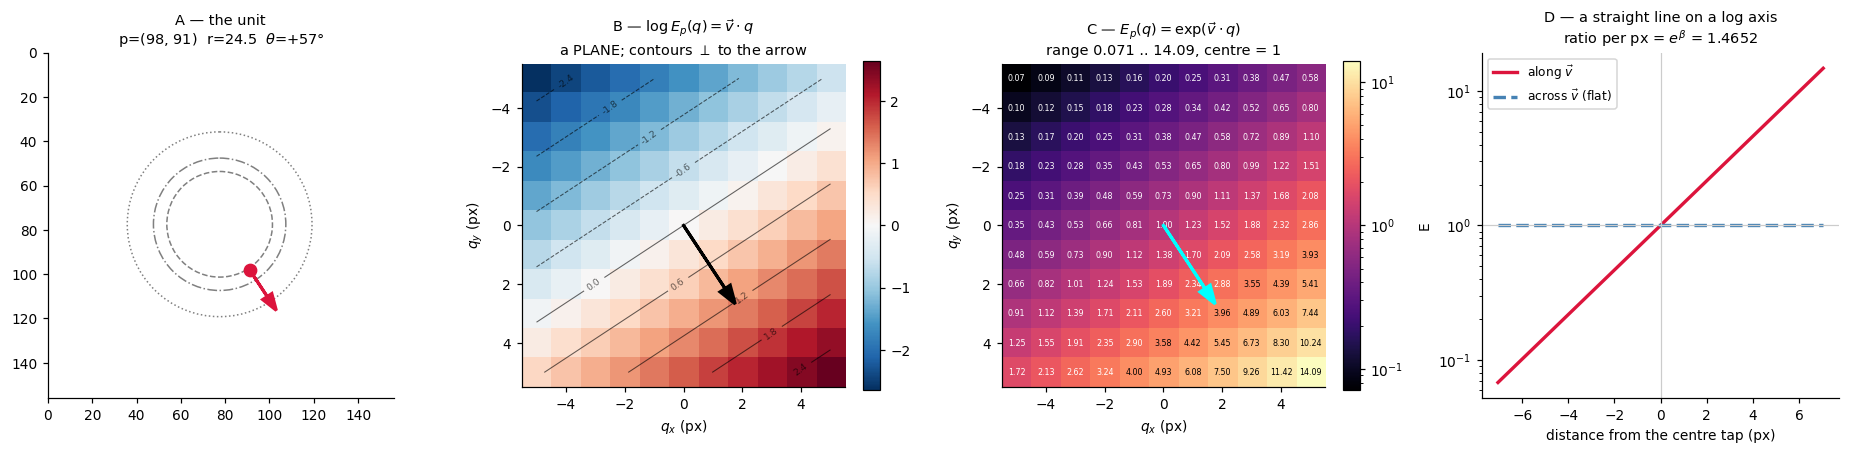

beta = +0.3820 1/px   vec = (+0.2101, +0.3190)   |vec| = 0.3820  (= |beta|)
E at the centre tap = 1.000000
ratio one px along vec = 1.4652;  across it = 1.0000


In [2]:
P = at_ecc(24.5, 57)          # near the profile's peak, on a diagonal
d = info(P); E = envelope(P)
uv = np.array([d["a"], d["b"]]); uvn = uv / np.linalg.norm(uv)

fig, ax = plt.subplots(1, 4, figsize=(17.0, 4.2))

def arrow(a_, sc=3.2, c="k"):
    a_.arrow(0, 0, uvn[0]*sc, uvn[1]*sc, head_width=0.42, length_includes_head=True,
             color=c, lw=2.0, zorder=6)

ext = [-PAD-.5, PAD+.5, PAD+.5, -PAD-.5]
# A: where the unit is
ax[0].set_aspect("equal")
for r0, ls in ((ZONES["core"], "--"), (ZONES["rfov"], "-."), (ZONES["footprint"], ":")):
    ax[0].add_patch(Circle((CY, CY), r0, fill=False, ec="0.5", lw=1.0, ls=ls))
ax[0].plot([P[1]], [P[0]], "o", color="crimson", ms=8, zorder=5)
ax[0].arrow(P[1], P[0], uvn[0]*22, uvn[1]*22, head_width=5, length_includes_head=True,
            color="crimson", lw=2.0, zorder=5)
ax[0].set_xlim(0, HW[1]); ax[0].set_ylim(HW[0], 0)
ax[0].set_title(f"A — the unit\np={P}  r={d['r']:.1f}  $\\theta$={d['th']:+.0f}$\\degree$")

# B: log E = the plane
im = ax[1].imshow(torch.log(E), cmap="RdBu_r", extent=ext,
                  vmin=-abs(torch.log(E)).max(), vmax=abs(torch.log(E)).max())
cs = ax[1].contour(QX, QY, torch.log(E), levels=9, colors="k", linewidths=0.7, alpha=0.6)
ax[1].clabel(cs, fontsize=6, fmt="%.1f")
arrow(ax[1]); fig.colorbar(im, ax=ax[1], fraction=0.046)
ax[1].set_title(r"B — $\log E_p(q)=\vec v\cdot q$" "\na PLANE; contours $\\perp$ to the arrow")

# C: E itself, annotated
im = ax[2].imshow(E, cmap="magma", norm=plt.matplotlib.colors.LogNorm(), extent=ext)
for i in range(KS):
    for j in range(KS):
        ax[2].text(QQ[j], QQ[i], f"{float(E[i,j]):.2f}", ha="center", va="center", fontsize=5.2,
                   color="w" if E[i, j] < E.max()*0.25 else "k")
arrow(ax[2], c="cyan"); fig.colorbar(im, ax=ax[2], fraction=0.046)
ax[2].set_title(f"C — $E_p(q)=\\exp(\\vec v\\cdot q)$\nrange {float(E.min()):.3f} .. "
                f"{float(E.max()):.2f}, centre = 1")

# D: cuts
t = np.linspace(-PAD*1.41, PAD*1.41, 200)
al = np.exp(d["beta"] * t)                                  # along vec
ax[3].semilogy(t, al, lw=2.2, color="crimson", label=r"along $\vec v$")
ax[3].semilogy(t, np.ones_like(t), lw=2.2, color="steelblue", ls="--",
               label=r"across $\vec v$ (flat)")
ax[3].axhline(1, color="0.8", lw=0.8); ax[3].axvline(0, color="0.8", lw=0.8)
ax[3].set_xlabel("distance from the centre tap (px)"); ax[3].set_ylabel("E")
ax[3].set_title(f"D — a straight line on a log axis\nratio per px = "
                f"$e^{{\\beta}}$ = {math.exp(d['beta']):.4f}")
ax[3].legend(fontsize=8)
for a_ in ax[1:3]:
    a_.set_xlabel("$q_x$ (px)"); a_.set_ylabel("$q_y$ (px)")
fig.tight_layout(); plt.show()

print(f"beta = {d['beta']:+.4f} 1/px   vec = ({d['a']:+.4f}, {d['b']:+.4f})   |vec| = "
      f"{np.linalg.norm(uv):.4f}  (= |beta|)")
print(f"E at the centre tap = {float(E[PAD,PAD]):.6f}")
print(f"ratio one px along vec = {math.exp(d['beta']):.4f};  across it = 1.0000")

---
## 4 — same `beta`, different `theta`: the ramp rotates

Six units at the **same eccentricity**, so all six have the identical `beta` and the identical
`|vec|`. Only the direction differs — and the ramp turns with it. Shared colour scale, so the panels
are directly comparable.

Watch the corners: the range is wider on the diagonals than on the axes, because the 11x11 window
reaches `5*sqrt(2) = 7.07 px` diagonally against `5 px` on-axis.

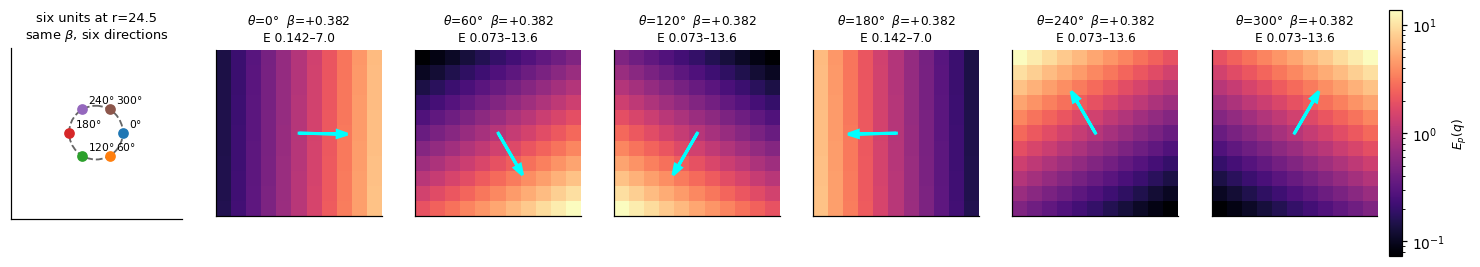

In [3]:
R_RING, ANG = 24.5, [0, 60, 120, 180, 240, 300]
Es = [(a_, envelope(at_ecc(R_RING, a_))) for a_ in ANG]
vmin = min(float(e.min()) for _, e in Es); vmax = max(float(e.max()) for _, e in Es)

fig, ax = plt.subplots(1, len(ANG) + 1, figsize=(2.35*(len(ANG)+1), 2.9))
ax[0].set_aspect("equal")
ax[0].add_patch(Circle((CY, CY), R_RING, fill=False, ec="0.4", lw=1.2, ls="--"))
for a_ in ANG:
    p = at_ecc(R_RING, a_)
    ax[0].plot([p[1]], [p[0]], "o", ms=6, color=plt.cm.tab10(ANG.index(a_)))
    ax[0].annotate(f"{a_}$\\degree$", (p[1], p[0]), fontsize=7, xytext=(4, 4),
                   textcoords="offset points")
ax[0].set_xlim(0, HW[1]); ax[0].set_ylim(HW[0], 0); ax[0].set_xticks([]); ax[0].set_yticks([])
ax[0].set_title(f"six units at r={R_RING}\nsame $\\beta$, six directions", fontsize=8.5)

ext = [-PAD-.5, PAD+.5, PAD+.5, -PAD-.5]
for i, (a_, E_) in enumerate(Es):
    p = at_ecc(R_RING, a_); dd = info(p)
    n = math.hypot(dd["a"], dd["b"])
    im = ax[i+1].imshow(E_, cmap="magma", extent=ext,
                        norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax))
    ax[i+1].arrow(0, 0, dd["a"]/n*3.2, dd["b"]/n*3.2, head_width=0.45,
                  length_includes_head=True, color="cyan", lw=2.0)
    ax[i+1].set_title(f"$\\theta$={a_}$\\degree$  $\\beta$={dd['beta']:+.3f}\n"
                      f"E {float(E_.min()):.3f}–{float(E_.max()):.1f}", fontsize=8)
    ax[i+1].set_xticks([]); ax[i+1].set_yticks([])
fig.colorbar(im, ax=ax[1:], fraction=0.02, pad=0.01).set_label("$E_p(q)$", fontsize=8)
plt.show()

---
## 5 — what the ramp does to a real kernel

Per row, one channel. Columns:

1. `W_c` — the trained kernel, signed. Its `|w|` centre of mass is the black cross.
2. `E_p` — the ramp at this position (same for every channel).
3. `W_c * E_p * N` — the product, renormalised. New centre of mass, and the arrow from old to new.

Two things to check: **no tap changed sign** (the ramp is strictly positive, it only rescales), and
the centre of mass moved **along `vec`** — with a small perpendicular residual, because the kernel's
own orientation is not aligned with the radius.

p=(98, 91)  r=24.5  theta=+57 deg  beta=+0.3820

   ch    COM before (dy,dx)           COM after  along vec    perp       N   signs
    0      (+0.000, +0.000)   (+3.522, +1.466)       3.75    0.71  0.4542    kept
    1      (+0.000, +0.000)   (+2.411, +1.924)       3.07    0.28  0.5415    kept
    2      (-0.000, +0.000)   (+2.003, +1.641)       2.58    0.27  0.6100    kept


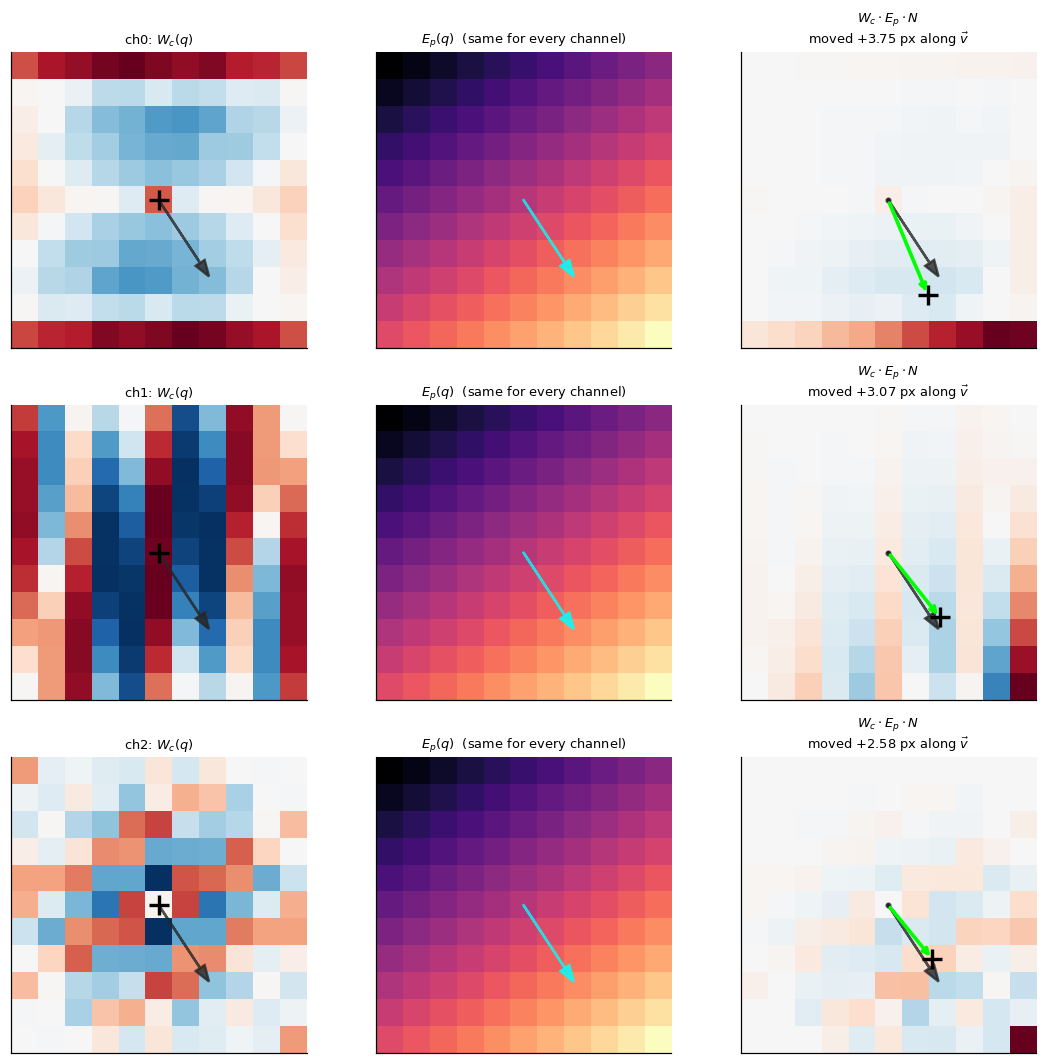

In [4]:
P = at_ecc(24.5, 57)
d = info(P); E = envelope(P)
uv = np.array([d["a"], d["b"]]); uvn = uv / np.linalg.norm(uv)
CHANS = [0, 1, 2]

fig, ax = plt.subplots(len(CHANS), 3, figsize=(10.2, 3.25*len(CHANS)))
ax = np.atleast_2d(ax)
ext = [-PAD-.5, PAD+.5, PAD+.5, -PAD-.5]
print(f"p={P}  r={d['r']:.1f}  theta={d['th']:+.0f} deg  beta={d['beta']:+.4f}\n")
print(f"  {'ch':>3}{'COM before (dy,dx)':>22}{'COM after':>20}{'along vec':>11}"
       f"{'perp':>8}{'N':>8}{'signs':>8}")
for row, c in enumerate(CHANS):
    Wc  = W[c]; eff = l1(Wc * E, float(Wc.abs().sum()))
    cy0, cx0 = com(Wc); cy1, cx1 = com(eff)
    dv   = np.array([cx1 - cx0, cy1 - cy0])
    along = float(dv @ uvn); perp = float(np.hypot(*dv) ** 2 - along ** 2) ** 0.5
    keep  = bool(((Wc > 0) == (eff > 0)).all())
    N     = float(Wc.abs().sum() / (Wc * E).abs().sum())
    for col, (M, t, cm) in enumerate((
            (Wc,  f"ch{c}: $W_c(q)$", "RdBu_r"),
            (E,   "$E_p(q)$  (same for every channel)", "magma"),
            (eff, "$W_c\\cdot E_p\\cdot N$", "RdBu_r"))):
        a_ = ax[row, col]
        if cm == "magma":
            a_.imshow(M, cmap=cm, extent=ext, norm=plt.matplotlib.colors.LogNorm())
        else:
            vv = float(M.abs().max())
            a_.imshow(M, cmap=cm, extent=ext, vmin=-vv, vmax=vv)
        a_.arrow(0, 0, uvn[0]*3.4, uvn[1]*3.4, head_width=0.4, length_includes_head=True,
                 color="0.15" if cm == "RdBu_r" else "cyan", lw=1.6, alpha=0.8)
        if col == 0:
            a_.plot([cx0], [cy0], "k+", ms=13, mew=2.2)
        if col == 2:
            a_.annotate("", xy=(cx1, cy1), xytext=(cx0, cy0),
                        arrowprops=dict(arrowstyle="->", color="lime", lw=2.4))
            a_.plot([cx1], [cy1], "k+", ms=13, mew=2.2)
            a_.plot([cx0], [cy0], "k.", ms=6, alpha=0.6)
            t += f"\nmoved {along:+.2f} px along $\\vec v$"
        a_.set_title(t, fontsize=8.5); a_.set_xticks([]); a_.set_yticks([])
    print(f"  {c:>3}      ({cy0:+.3f}, {cx0:+.3f})   ({cy1:+.3f}, {cx1:+.3f})"
          f"{along:>11.2f}{perp:>8.2f}{N:>8.4f}{'kept' if keep else 'FLIPPED':>8}")
fig.tight_layout(); plt.show()

---
## 6 — one `beta`, many displacements

`beta` is one number; the px it buys is not. It depends on the channel (each kernel has its own
structure) and on the angle between that kernel's carrier and the radius.

**Left**: achieved displacement vs `beta`, one thin line per channel, median in black. The dashed
line is the 5 px grid ceiling — `(k-1)/2`, the furthest an 11x11 window can put its centre of mass
on-axis. **Right**: at the profile's own peak `beta`, the whole distribution over channel x angle.

This is why the module learns `beta` and not a displacement: `beta` is a single well-defined number,
the px is not.

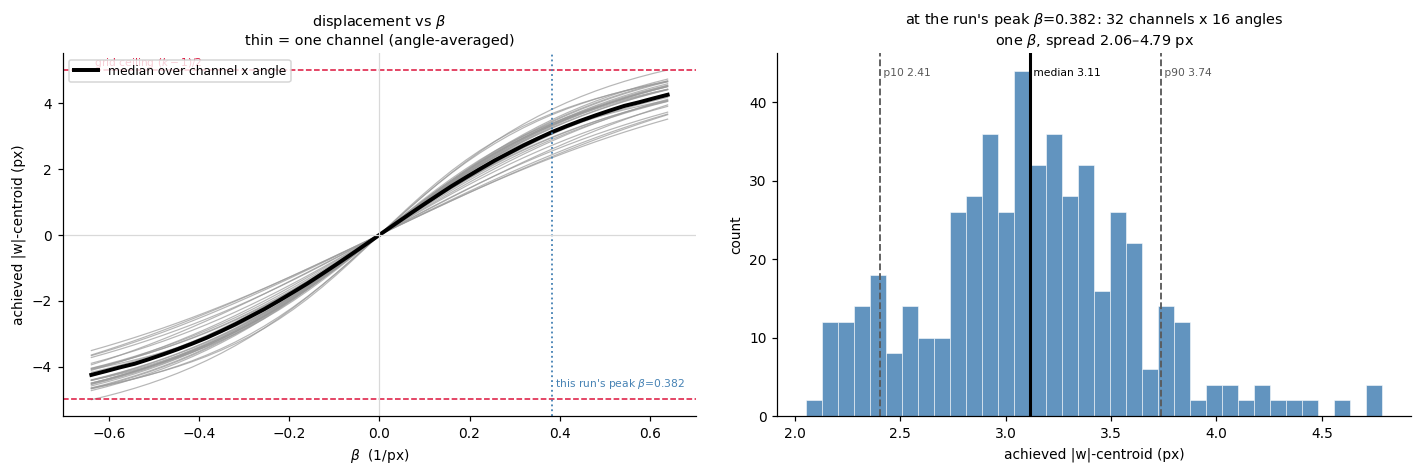

at beta=0.3821: median 3.11 px, p10-p90 2.41-3.74, full range 2.06-4.79


In [5]:
N_TH = 16
THS  = torch.arange(N_TH, dtype=torch.float32) * (2*math.pi/N_TH)
BETAS = np.linspace(-BETA_MAX, BETA_MAX, 41)

def achieved(betas, thetas):
    """(len(betas), n_theta*C) achieved |w|-centroid projected on rhat."""
    proj = QX[None]*torch.cos(thetas)[:,None,None] + QY[None]*torch.sin(thetas)[:,None,None]
    out = []
    for bb in betas:
        E_ = torch.exp(float(bb) * proj)                       # (T,k,k)
        m  = (W[None] * E_[:, None]).abs()                     # (T,C,k,k)
        t  = m.sum((-1,-2)).clamp_min(1e-12)
        cy = (m.sum(-1) * QQ).sum(-1) / t
        cx = (m.sum(-2) * QQ).sum(-1) / t
        out.append((cx*torch.cos(thetas)[:,None] + cy*torch.sin(thetas)[:,None]).reshape(-1))
    return torch.stack(out).numpy()

ACH = achieved(BETAS, THS)                                     # (41, 16*C)
fig, ax = plt.subplots(1, 2, figsize=(13.0, 4.4))

per_ch = ACH.reshape(len(BETAS), N_TH, C_N).mean(1)            # average over angle, per channel
for c in range(C_N):
    ax[0].plot(BETAS, per_ch[:, c], lw=0.8, color="0.6", alpha=0.7)
ax[0].plot(BETAS, np.median(ACH, axis=1), lw=2.6, color="k", label="median over channel x angle")
for s in (+1, -1):
    ax[0].axhline(s*(KS-1)/2, color="crimson", ls="--", lw=1.0)
ax[0].text(-BETA_MAX, (KS-1)/2, " grid ceiling $(k-1)/2$", fontsize=7, color="crimson", va="bottom")
pk = float(BETA.max())
ax[0].axvline(pk, color="steelblue", lw=1.2, ls=":")
ax[0].text(pk, -4.6, f" this run's peak $\\beta$={pk:.3f}", fontsize=7, color="steelblue")
ax[0].axhline(0, color="0.85", lw=0.8); ax[0].axvline(0, color="0.85", lw=0.8)
ax[0].set_xlabel(r"$\beta$  (1/px)"); ax[0].set_ylabel("achieved |w|-centroid (px)")
ax[0].set_title("displacement vs $\\beta$\nthin = one channel (angle-averaged)")
ax[0].legend(fontsize=8, loc="upper left")

at_pk = achieved([pk], THS)[0]
ax[1].hist(at_pk, bins=36, color="steelblue", alpha=0.85, edgecolor="w", linewidth=0.4)
for q_, cc, lab in ((10, "0.35", "p10"), (50, "k", "median"), (90, "0.35", "p90")):
    x = np.percentile(at_pk, q_)
    ax[1].axvline(x, color=cc, lw=2.0 if q_ == 50 else 1.2, ls="-" if q_ == 50 else "--")
    ax[1].text(x, ax[1].get_ylim()[1]*0.96, f" {lab} {x:.2f}", fontsize=7, color=cc, va="top")
ax[1].set_xlabel("achieved |w|-centroid (px)"); ax[1].set_ylabel("count")
ax[1].set_title(f"at the run's peak $\\beta$={pk:.3f}: {C_N} channels x {N_TH} angles\n"
                f"one $\\beta$, spread {at_pk.min():.2f}–{at_pk.max():.2f} px")
fig.tight_layout(); plt.show()

print(f"at beta={pk:.4f}: median {np.median(at_pk):.2f} px, "
      f"p10-p90 {np.percentile(at_pk,10):.2f}-{np.percentile(at_pk,90):.2f}, "
      f"full range {at_pk.min():.2f}-{at_pk.max():.2f}")

---
## 7 — the achieved displacement, over the whole map

Now put it together: at each sampled position, compute the **actual** centre-of-mass shift of the
real kernels (median over channels) and draw it as an arrow.

**Grey** = the pure radial direction `vec(p)` for reference. **Coloured** = where the mass actually
went. They mostly agree, and where they don't, the gap is the kernels' own anisotropy pulling the
result off the radius.

This is the picture the whole mechanism was building towards: a retinotopic field of receptive-field
displacements, learned from 10 parameters.

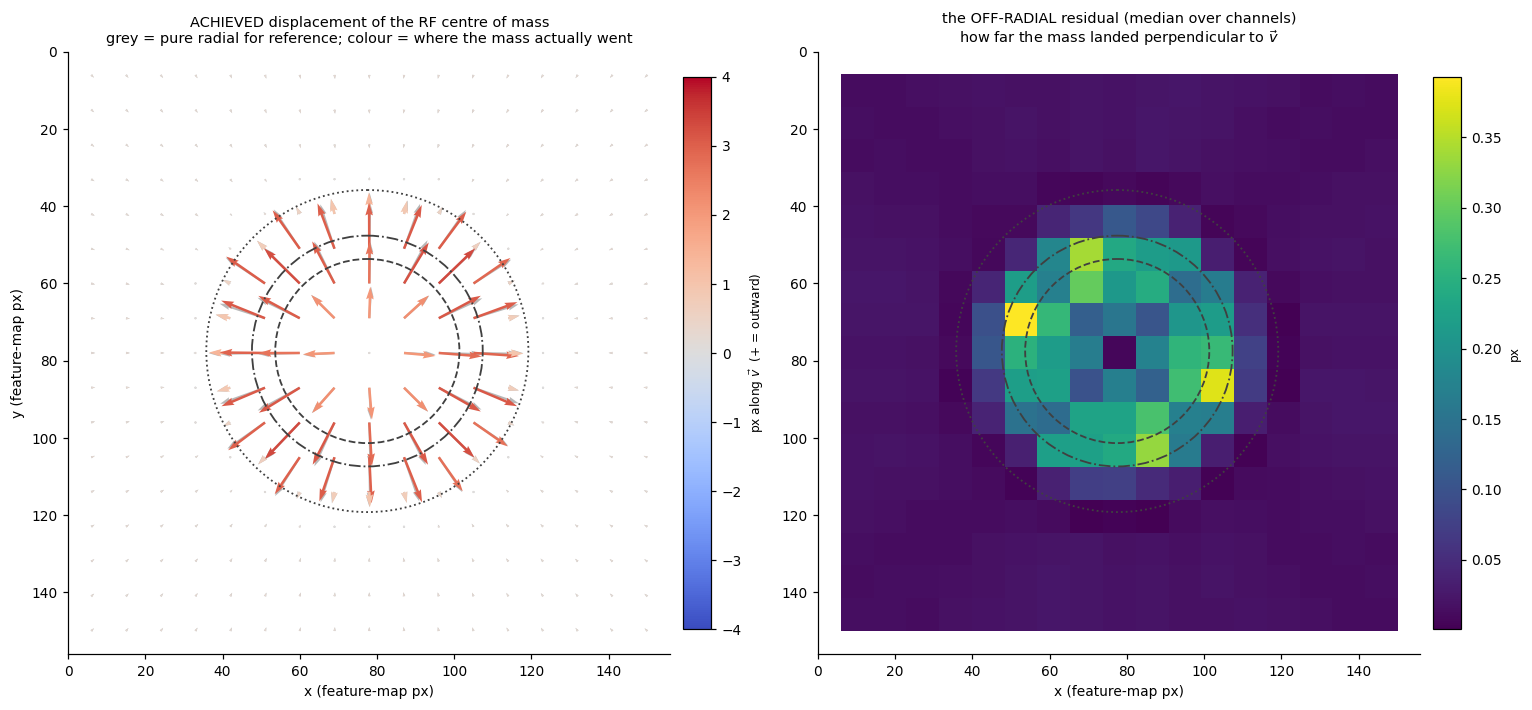

over ALL 289 sampled positions:
  radial displacement : median +0.25 px, max +3.32
  off-radial residual : median 0.02 px, max 0.39

restricted to r < 42 px (inside the scotoma footprint, where the profile is actually non-zero) -- 69 positions:
  radial displacement : median +2.69 px, max +3.32
  off-radial residual : median 0.17 px, max 0.39
  -> the residual is 6% of the radial move

The far field looks empty because beta ~ 0 there, not because the operator is weak: the displacement
field is concentrated in r ~ 5-45 px, which is where the profile lives.


In [6]:
ST = 9
pys, pxs = np.mgrid[6:HW[0]-5:ST, 6:HW[1]-5:ST]
pos = np.stack([pys.ravel(), pxs.ravel()], 1)

av = Aa.numpy()[pos[:,0], pos[:,1]]; bv = Bb.numpy()[pos[:,0], pos[:,1]]
E_all = torch.exp(torch.tensor(av)[:,None,None]*QX + torch.tensor(bv)[:,None,None]*QY)  # (P,k,k)
m  = (W[None] * E_all[:, None]).abs()                    # (P,C,k,k)
t  = m.sum((-1,-2)).clamp_min(1e-12)
cyc = ((m.sum(-1) * QQ).sum(-1) / t).numpy()             # (P,C)  per channel, NOT median yet
cxc = ((m.sum(-2) * QQ).sum(-1) / t).numpy()
nrm = np.hypot(av, bv); nrm[nrm == 0] = 1
ux, uy = av/nrm, bv/nrm                                  # unit radial per position
# PROJECT PER CHANNEL, THEN take the median. Doing it the other way round -- projecting the
# channel-median centroid -- cancels the per-channel anisotropy against itself and reports an
# off-radial residual of ~0, which is an artefact of the averaging, not a property of the operator.
along_c = cxc*ux[:, None] + cyc*uy[:, None]              # (P,C)
perp_c  = np.sqrt(np.maximum(cxc**2 + cyc**2 - along_c**2, 0))
along, perp = np.median(along_c, 1), np.median(perp_c, 1)
cx, cy = np.median(cxc, 1), np.median(cyc, 1)            # for the arrows only

fig, ax = plt.subplots(1, 2, figsize=(14.0, 6.4))
for a_ in ax:
    a_.set_aspect("equal"); a_.set_xlim(0, HW[1]); a_.set_ylim(HW[0], 0)
    for r0, ls in ((ZONES["core"], "--"), (ZONES["rfov"], "-."), (ZONES["footprint"], ":")):
        a_.add_patch(Circle((CY, CY), r0, fill=False, ec="0.25", lw=1.2, ls=ls, zorder=5))
    a_.set_xlabel("x (feature-map px)")

# QUIVER ON AN INVERTED Y AXIS: angles="xy" is MANDATORY here, not a preference.
# matplotlib defaults to angles="uv", which resolves the arrow direction in SCREEN space (y up).
# These axes are image-style inverted (set_ylim(H, 0)), so with the default the VERTICAL component
# is drawn BACKWARDS while the horizontal one is not: arrows above and below the fovea flip to point
# inward while left/right still point outward, and the field renders as a saddle that is not there.
# Verified: with angles="uv" a V=+1 arrow draws UP on an inverted axis; with angles="xy" it draws
# DOWN, which is what "data y increases" means here. scale_units="xy" then puts the LENGTH in
# feature-map px too, so `scale` reads as "vector magnitude per px of arrow".
SC = 0.25                       # vector magnitude (px of RF shift) per px of drawn arrow
ax[0].quiver(pos[:,1], pos[:,0], av/nrm*along, bv/nrm*along,
             color="0.72", pivot="tail", angles="xy", scale_units="xy", scale=SC,
             width=0.0035, zorder=2)
q = ax[0].quiver(pos[:,1], pos[:,0], cx, cy, along, cmap="coolwarm", pivot="tail",
                 angles="xy", scale_units="xy", scale=SC,
                 norm=plt.Normalize(-4, 4), width=0.0042, zorder=3)
ax[0].set_ylabel("y (feature-map px)")
ax[0].set_title("ACHIEVED displacement of the RF centre of mass\n"
                "grey = pure radial for reference; colour = where the mass actually went")
fig.colorbar(q, ax=ax[0], fraction=0.043, pad=0.02).set_label("px along $\\vec v$  (+ = outward)",
                                                              fontsize=8)

im = ax[1].imshow(perp.reshape(pys.shape), cmap="viridis",
                  extent=[pxs.min(), pxs.max(), pys.max(), pys.min()])
ax[1].set_title("the OFF-RADIAL residual (median over channels)\n"
                "how far the mass landed perpendicular to $\\vec v$")
fig.colorbar(im, ax=ax[1], fraction=0.043, pad=0.02).set_label("px", fontsize=8)
fig.tight_layout(); plt.show()

inner = np.hypot(pos[:,0]-CY, pos[:,1]-CY) < ZONES["footprint"]
print(f"over ALL {len(pos)} sampled positions:")
print(f"  radial displacement : median {np.median(along):+.2f} px, max {along.max():+.2f}")
print(f"  off-radial residual : median {np.median(perp):.2f} px, max {perp.max():.2f}")
print(f"\nrestricted to r < {ZONES['footprint']:.0f} px (inside the scotoma footprint, where the "
      f"profile is actually non-zero) -- {int(inner.sum())} positions:")
print(f"  radial displacement : median {np.median(along[inner]):+.2f} px, "
      f"max {along[inner].max():+.2f}")
print(f"  off-radial residual : median {np.median(perp[inner]):.2f} px, "
      f"max {perp[inner].max():.2f}")
print(f"  -> the residual is {100*np.median(perp[inner])/max(np.median(np.abs(along[inner])),1e-9):.0f}% "
      f"of the radial move")
print(f"\nThe far field looks empty because beta ~ 0 there, not because the operator is weak: "
      f"the displacement\nfield is concentrated in r ~ 5-45 px, which is where the profile lives.")